# Quickstart

In [1]:
import immunowave as iw
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Define a model

Models are defined by subclassing the abstract class `iw.Model`.

### FitzHugh-Nagumo + Bacteria

The dynamical variables $(A, B, R)$ denote
the concentration of antimicrobial peptide, repression, and bacteria, respectively,
and satisfy

$$
\begin{align*}
\partial_t A &= \nabla^2 A + A (A - \theta) (1 - A) + \eta B - \rho R \\
\partial_t B &= \xi \nabla^2 B + \lambda B (1-B) - \mu A B\\
\partial_t R &= \epsilon (A - R)
\end{align*}
$$

Parameters:
- $\alpha$: Diffusion coefficient of antimicrobial peptide.
- $\theta$: Threshold for antimicrobial peptide production.
- $\eta$: Rate of antimicrobial peptide growth response to bacteria.
- $\rho$: Rate of antimicrobial peptide degradation response to repression.
- $\epsilon$: Rate of repression production.
- $\xi$: Diffusion coefficient of bacteria.
- $\lambda$: Rate of bacteria growth.
- $\mu$: Rate of bacteria death response to antimicrobial peptide.
    

In [23]:
class FHNB_state(eqx.Module):
    A: iw.ScalarField
    B: iw.ScalarField
    R: iw.ScalarField

    def __post_init__(self):
        self.A.check_aligned(self.B)
        self.A.check_aligned(self.R)

In [24]:
class FHNB_model(iw.Model):
    α: float
    θ: float
    η: float
    ρ: float
    ε: float
    ξ: float
    λ: float
    μ: float

    def __call__(self, t, state, args=None):
        A, B, R = state.A, state.B, state.R
        dAdt = (
            self.α * A.laplacian(bc="neumann")
            + A * (A - self.θ) * (1 - A)
            + self.η * B
            - self.ρ * R
        )
        dBdt = (
            self.ξ * B.laplacian(bc="neumann") + self.λ * B * (1 - B) - self.μ * A * B
        )
        dRdt = self.ε * (A - R)

        return FHNB_state(dAdt, dBdt, dRdt)

    # NOTE: 1d only
    @staticmethod
    def boundary_metric(state):
        A, B, R = state.A, state.B, state.R
        return max(A.values[0], A.values[-1])

In [25]:
model = FHNB_model(α=1.0, θ=0.1, η=0.2, ρ=0.0, ε=0.0, ξ=1.0, λ=0.5, μ=1.0)
model

FHNB_model(α=1.0, θ=0.1, η=0.2, ρ=0.0, ε=0.0, ξ=1.0, λ=0.5, μ=1.0)

## Initialize fields

Spatial discretization

In [26]:
L = 100.0
n = 100

shape = (n,)
lb = [-L / 2]
h = L / (n - 1)

Initialize the $A$ and $R$ fields to zero and the $B$ field to a finite impulse at the center of the domain.

In [27]:
A = iw.ScalarField(shape, lb, h, 0)
B = iw.ScalarField(shape, lb, h, fn=lambda x: jnp.where(jnp.abs(x) < h / 2, 1 / h, 0))
R = iw.ScalarField(shape, lb, h, 0)

B.integral()

Array(1., dtype=float64)

In [28]:
state0 = FHNB_state(A, B, R)

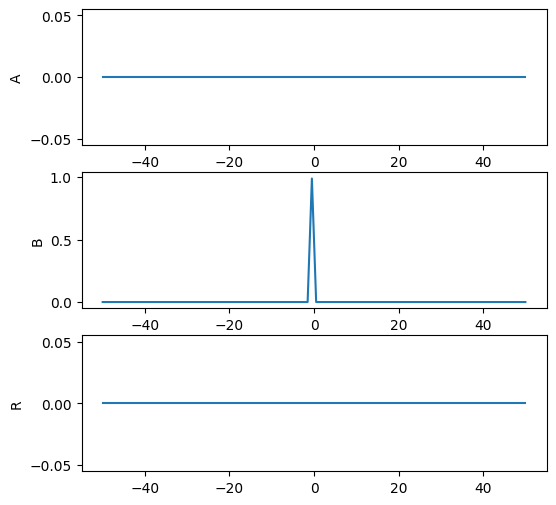

In [29]:
model.plot(state0)

## Solve

Define time domain

In [30]:
t0 = 0.0
t1 = 50.0
t = np.linspace(t0, t1, 20)

Solve

In [31]:
import jax.tree_util as jtu

jtu.tree_structure(state0) == jtu.tree_structure(model(0, state0))

True

In [32]:
solution = model.solve(state0, t=t, max_steps=100000)

In [33]:
solution

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[20],
  ys=FHNB_state(
    A=ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    ),
    B=ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    ),
    R=ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    )
  ),
  interpolation=None,
  stats={
    'max_steps':
    100000,
    'num_accepted_steps':
    i64[],
    'num_rejected_steps':
    i64[],
    'num_steps':
    i64[]
  },
  result=i64[],
  solver_state=None,
  controller_state=None,
  made_jump=None
)

## Plot

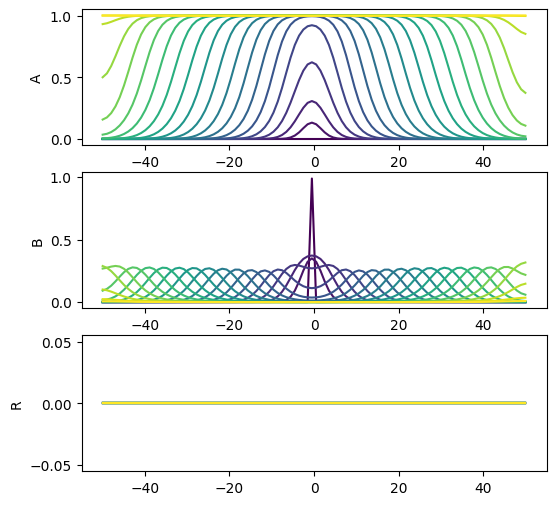

In [34]:
model.plot(solution)